# Body Measurement Inference
Run each cell in order

In [ ]:
import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "install",
    "numpy==1.26.4", "--quiet", "--force-reinstall"])
subprocess.run([sys.executable, "-m", "pip", "install",
    "onnxruntime", "onnx", "onnxscript", "--quiet"])
print("✓ Dependencies installed")

In [1]:
import os, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import cv2
import torch
import torch.nn as nn
import onnxruntime as ort
from torchvision import transforms, models
warnings.filterwarnings("ignore")

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device   : {DEVICE}")

PyTorch  : 2.9.0+cu126
CUDA     : True
Device   : cuda


In [2]:
MODEL_PATH  = '/kaggle/input/datasets/aminalawal/model-infor/bodym_final_model.pth'
SCALER_PATH = '/kaggle/input/datasets/aminalawal/model-infor/label_scaler.pkl'
OUTPUT_DIR  = '/kaggle/working'
ONNX_PATH   = os.path.join(OUTPUT_DIR, 'bodym_model.onnx')
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE      = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
MEASUREMENT_COLS = [
    'ankle', 'arm-length', 'bicep', 'calf', 'chest', 'forearm',
    'height', 'hip', 'leg-length', 'shoulder-breadth',
    'shoulder-to-crotch', 'thigh', 'waist', 'wrist'
]
NUM_OUTPUTS = len(MEASUREMENT_COLS)
print(f" Config ready — {NUM_OUTPUTS} measurements")

✓ Config ready — 14 measurements


In [3]:
class DualBranchBodyM(nn.Module):
    def __init__(self, num_outputs, dropout=0.3):
        super().__init__()
        self.front_branch = self._build_backbone()
        self.side_branch  = self._build_backbone()
        feat_dim  = 1408
        fused_dim = feat_dim * 2 + 3
        self.head = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_outputs),
        )

    @staticmethod
    def _build_backbone():
        backbone = models.efficientnet_b2(weights=None)
        backbone.classifier = nn.Identity()
        return backbone

    def forward(self, front_img, side_img, aux):
        front_feat = self.front_branch(front_img)
        side_feat  = self.side_branch(side_img)
        fused      = torch.cat([front_feat, side_feat, aux], dim=1)
        return self.head(fused)

print(" Architecture defined")

✓ Architecture defined


In [4]:
model = DualBranchBodyM(num_outputs=NUM_OUTPUTS).to(DEVICE)
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"✓ Model loaded — Test MAE: {checkpoint['test_mean_mae_cm']:.3f} cm")

with open(SCALER_PATH, 'rb') as f:
    scaler = pickle.load(f)
print("Scaler loaded")

✓ Model loaded — Test MAE: 1.191 cm
✓ Scaler loaded


In [5]:
class DualBranchONNXWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        front = x[:, 0:3, :, :]
        side  = x[:, 3:6, :, :]
        aux   = x[:, 6:9, 0, 0]
        return self.model(front, side, aux)

onnx_wrapper = DualBranchONNXWrapper(model).cpu().eval()
dummy_input  = torch.zeros(1, 9, IMG_SIZE, IMG_SIZE)

torch.onnx.export(
    onnx_wrapper,
    dummy_input,
    ONNX_PATH,
    input_names   = ['input'],
    output_names  = ['measurements'],
    dynamic_axes  = {'input': {0: 'batch_size'}, 'measurements': {0: 'batch_size'}},
    opset_version = 18,
    verbose       = False,
)
print(f"ONNX exported → {ONNX_PATH}")
print(f"  File size: {os.path.getsize(ONNX_PATH)/1024/1024:.1f} MB")

W0312 20:49:42.533000 111 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0312 20:49:42.534000 111 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0312 20:49:42.536000 111 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0312 20:49:42.538000 111 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


Applied 281 of general pattern rewrite rules.
✓ ONNX exported → /kaggle/working/bodym_model.onnx
  File size: 2.1 MB


In [6]:
import subprocess
import sys
subprocess.run([sys.executable, "-m", "pip", "install", "onnx2tf", "--quiet"])

tflite_dir = os.path.join(OUTPUT_DIR, 'tflite_output')
result = subprocess.run([
    sys.executable, "-m", "onnx2tf",
    "-i", ONNX_PATH,
    "-o", tflite_dir,
    "-oiqt",
    "--non_verbose"
], capture_output=True, text=True)

print(result.stdout[-2000:])
if result.stderr:
    print("STDERR:", result.stderr[-500:])

print("\nGenerated TFLite files:")
for f in os.listdir(tflite_dir):
    size = os.path.getsize(os.path.join(tflite_dir, f))
    print(f"  {f}  ({size/1024/1024:.1f} MB)")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.3/220.3 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.8/374.8 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.4 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
kaggle-environments 1.27.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
a2a-sdk 0.3.23 requires protobuf>=5.29.5, but you have protobuf 4.25.5 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.5 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, b

Saved artifact at '/kaggle/working/tflite_output'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 9), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(1, 14), dtype=tf.float32, name=None)


ERROR: For models that have multiple input OPs and need to perform INT8 quantization calibration using non-rgb-image/non-rgba-image input tensors, specify the calibration data with --quant_calib_input_op_name_np_data_path. model_input[n].shape: (None, 224, 224, 9)

STDERR: 1773348894.975644     175 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1773348898.606552     175 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00:1773348898.606738     175 single_machine.cc:374] Starting new session
W0000 00:00:1773348902.763281     175 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1773348902.763310     175 t

In [7]:
import json

scaler_params = {
    'mean':             scaler.mean_.tolist(),
    'scale':            scaler.scale_.tolist(),
    'measurement_cols': MEASUREMENT_COLS,
    'img_size':         IMG_SIZE,
}
scaler_path = os.path.join(OUTPUT_DIR, 'scaler_params.json')
with open(scaler_path, 'w') as f:
    json.dump(scaler_params, f, indent=2)
print(f"scaler_params.json saved → {scaler_path}")

✓ scaler_params.json saved → /kaggle/working/scaler_params.json


In [8]:
def load_segmentation_model():
    seg_model = models.segmentation.lraspp_mobilenet_v3_large(
        weights=models.segmentation.LRASPP_MobileNet_V3_Large_Weights.COCO_WITH_VOC_LABELS_V1
    )
    seg_model.eval().to(DEVICE)
    print(" Segmentation model loaded")
    return seg_model

seg_model = load_segmentation_model()

Downloading: "https://download.pytorch.org/models/lraspp_mobilenet_v3_large-d234d4ea.pth" to /root/.cache/torch/hub/checkpoints/lraspp_mobilenet_v3_large-d234d4ea.pth


100%|██████████| 12.5M/12.5M [00:00<00:00, 61.4MB/s]

✓ Segmentation model loaded


In [9]:
def extract_silhouette(image_path, seg_model):
    """Extract person silhouette from a photo using semantic segmentation."""
    PERSON_CLASS = 15
    img_pil      = Image.open(image_path).convert('RGB')
    orig_w, orig_h = img_pil.size

    preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    input_tensor = preprocess(img_pil).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = seg_model(input_tensor)['out']

    pred = output.argmax(dim=1).squeeze().cpu().numpy()
    mask = (pred == PERSON_CLASS).astype(np.uint8) * 255

    mask_pil = Image.fromarray(mask).resize((orig_w, orig_h), Image.NEAREST)
    mask     = np.array(mask_pil)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20, 20))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_DILATE, kernel)

    return Image.fromarray(mask, mode='L')


def preprocess_silhouette(silhouette_pil):
    """Convert silhouette PIL image → (3, 224, 224) numpy array."""
    tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    return tf(silhouette_pil.convert('RGB')).numpy()  # (3, 224, 224) numpy


def visualize_silhouettes(front_orig, side_orig, front_sil, side_sil):
    """Show original photos alongside extracted silhouettes."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    fig.suptitle('Original Photos → Extracted Silhouettes', fontsize=14, fontweight='bold')
    axes[0, 0].imshow(Image.open(front_orig)); axes[0, 0].set_title('Original — Frontal'); axes[0, 0].axis('off')
    axes[0, 1].imshow(Image.open(side_orig));  axes[0, 1].set_title('Original — Lateral'); axes[0, 1].axis('off')
    axes[1, 0].imshow(front_sil, cmap='gray'); axes[1, 0].set_title('Silhouette — Frontal'); axes[1, 0].axis('off')
    axes[1, 1].imshow(side_sil, cmap='gray');  axes[1, 1].set_title('Silhouette — Lateral'); axes[1, 1].axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'silhouettes.png'), dpi=150, bbox_inches='tight')
    plt.show()

print("Silhouette functions ready")

✓ Silhouette functions ready


In [10]:
@torch.no_grad()
def predict_pytorch(front_path, side_path, gender, height_cm, weight_kg, show_silhouettes=True):
    """Run inference using PyTorch model — use as reference/ground truth."""
    print("Step 1/3 — Extracting silhouettes...")
    front_sil = extract_silhouette(front_path, seg_model)
    side_sil  = extract_silhouette(side_path,  seg_model)
    print("Silhouettes extracted")

    if show_silhouettes:
        visualize_silhouettes(front_path, side_path, front_sil, side_sil)

    print("Step 2/3 — Preprocessing...")
    front_tensor = torch.from_numpy(preprocess_silhouette(front_sil)).unsqueeze(0).to(DEVICE)
    side_tensor  = torch.from_numpy(preprocess_silhouette(side_sil)).unsqueeze(0).to(DEVICE)
    gender_val   = 1.0 if gender.lower().strip() == 'male' else 0.0
    aux = torch.tensor([[gender_val, float(height_cm), float(weight_kg)]],
                       dtype=torch.float32).to(DEVICE)
    print("Tensors ready")

    print("Step 3/3 — Running PyTorch model...")
    model.to(DEVICE).eval()
    pred_normalized = model(front_tensor, side_tensor, aux)
    pred_cm = scaler.inverse_transform(pred_normalized.cpu().numpy())[0]
    print("Predictions complete")

    return dict(zip(MEASUREMENT_COLS, pred_cm))

print("PyTorch inference function ready")

✓ PyTorch inference function ready


In [11]:
def predict_onnx(front_path, side_path, gender, height_cm, weight_kg, show_silhouettes=False):
    """Run inference using ONNX model — mirrors predict_pytorch exactly."""
    print("Step 1/3 — Extracting silhouettes...")
    front_sil = extract_silhouette(front_path, seg_model)
    side_sil  = extract_silhouette(side_path,  seg_model)
    print("Silhouettes extracted")

    if show_silhouettes:
        visualize_silhouettes(front_path, side_path, front_sil, side_sil)

    print("Step 2/3 — Preprocessing...")
    front_np   = preprocess_silhouette(front_sil)   # (3, 224, 224)
    side_np    = preprocess_silhouette(side_sil)    # (3, 224, 224)
    gender_val = 1.0 if gender.lower().strip() == 'male' else 0.0
    aux_vals   = np.array([gender_val, float(height_cm), float(weight_kg)], dtype=np.float32)
    aux_tiled  = np.tile(aux_vals[:, None, None], (1, IMG_SIZE, IMG_SIZE))  # (3, 224, 224)

    # Build 9-channel input (1, 9, 224, 224)
    input_tensor = np.concatenate([front_np, side_np, aux_tiled], axis=0)[np.newaxis].astype(np.float32)
    print(f"  Input shape : {input_tensor.shape}")   # should be (1, 9, 224, 224)
    print("Tensors ready")

    print("Step 3/3 — Running ONNX model...")
    session    = ort.InferenceSession(ONNX_PATH)
    input_name = session.get_inputs()[0].name
    raw_output = session.run(None, {input_name: input_tensor})[0][0]
    print(f"  Raw output  : {raw_output}")           # should be ~[-3, 3]

    # Apply inverse scaler
    predicted_cm = (raw_output * np.array(scaler.scale_, dtype=np.float32)) \
                 + np.array(scaler.mean_, dtype=np.float32)
    print("Predictions complete")

    return dict(zip(MEASUREMENT_COLS, predicted_cm))

print("ONNX inference function ready")

✓ ONNX inference function ready


In [12]:
def print_results_table(predictions, gender, height_cm, weight_kg):
    print(f'\n{"="*45}')
    print(f'  PREDICTED BODY MEASUREMENTS')
    print(f'  Gender: {gender.capitalize()}  |  Height: {height_cm}cm  |  Weight: {weight_kg}kg')
    print(f'{"="*45}')
    print(f'  {"Measurement":<22} {"Predicted (cm)":>12}')
    print(f'  {"-"*40}')
    for name, value in predictions.items():
        flag = ' ⚠' if name in ['chest', 'waist', 'hip'] else ''
        print(f'  {name:<22} {value:>10.1f}{flag}')
    print(f'{"="*45}')
    print(f'  ⚠ = higher uncertainty measurement')


def display_results(predictions, gender, height_cm, weight_kg, front_path):
    fig, axes = plt.subplots(1, 2, figsize=(16, 9))
    fig.suptitle('Body Measurement Predictions', fontsize=16, fontweight='bold')

    front_sil = extract_silhouette(front_path, seg_model)
    axes[0].imshow(front_sil, cmap='gray')
    axes[0].set_title('Frontal Silhouette', fontsize=12)
    axes[0].axis('off')

    names  = list(predictions.keys())
    values = list(predictions.values())
    colors = ['#e67e22' if n in ['chest', 'waist', 'hip'] else '#3498db' for n in names]
    bars   = axes[1].barh(names, values, color=colors, edgecolor='white', height=0.6)

    for bar, val in zip(bars, values):
        axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f} cm', va='center', fontsize=10, fontweight='bold')

    axes[1].set_title(f'Gender: {gender.capitalize()}  |  Height: {height_cm}cm  |  Weight: {weight_kg}kg', fontsize=11)
    axes[1].set_xlabel('cm', fontsize=11)
    axes[1].grid(axis='x', alpha=0.3)
    axes[1].set_xlim(0, max(values) * 1.15)
    axes[1].legend(handles=[
        mpatches.Patch(color='#3498db', label='Measurements'),
        mpatches.Patch(color='#e67e22', label='Higher uncertainty (chest/waist/hip)'),
    ], fontsize=9, loc='lower right')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'predictions.png'), dpi=150, bbox_inches='tight')
    plt.show()

print("Display helpers ready")

✓ Display helpers ready


In [13]:
FRONT_PHOTO = '/kaggle/input/datasets/aminalawal/test-ima/frontal.jpeg'
SIDE_PHOTO  = '/kaggle/input/datasets/aminalawal/test-ima/lateral.jpeg'
GENDER      = 'female'    # 'male' or 'female'
HEIGHT_CM   = 163.0
WEIGHT_KG   = 65.0
print(f"Inputs set — {GENDER}, {HEIGHT_CM}cm, {WEIGHT_KG}kg")

✓ Inputs set — female, 163.0cm, 65.0kg


=== PyTorch Inference ===
Step 1/3 — Extracting silhouettes...
  ✓ Silhouettes extracted


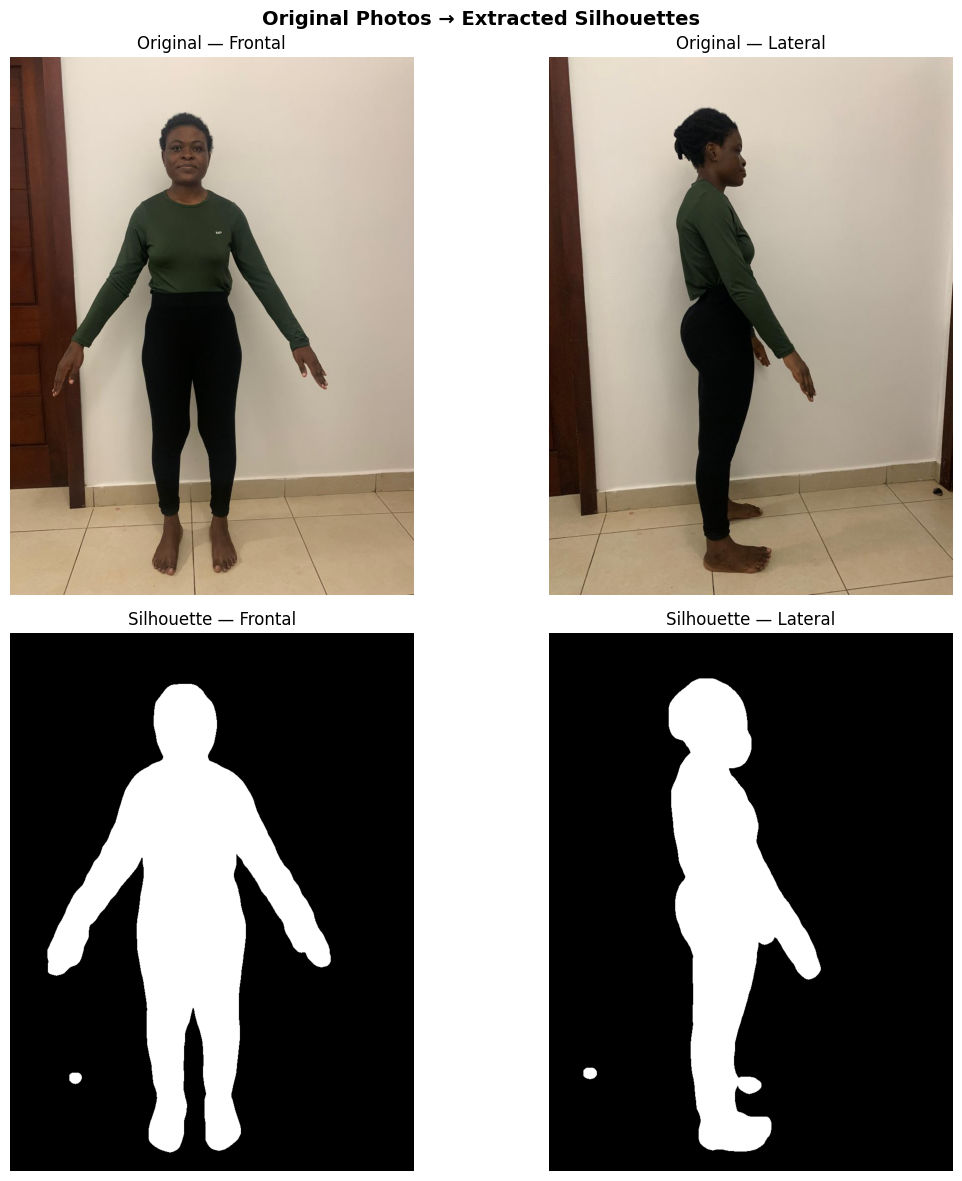

Step 2/3 — Preprocessing...
  ✓ Tensors ready
Step 3/3 — Running PyTorch model...
  ✓ Predictions complete

  PREDICTED BODY MEASUREMENTS
  Gender: Female  |  Height: 163.0cm  |  Weight: 65.0kg
  Measurement            Predicted (cm)
  ----------------------------------------
  ankle                        23.8
  arm-length                   46.7
  bicep                        29.7
  calf                         37.5
  chest                        97.4 ⚠
  forearm                      25.8
  height                      163.4
  hip                          99.4 ⚠
  leg-length                   74.2
  shoulder-breadth             33.6
  shoulder-to-crotch           60.6
  thigh                        52.6
  waist                        85.5 ⚠
  wrist                        16.7
  ⚠ = higher uncertainty measurement


In [14]:
print("=== PyTorch Inference ===")
pytorch_predictions = predict_pytorch(
    FRONT_PHOTO, SIDE_PHOTO, GENDER, HEIGHT_CM, WEIGHT_KG,
    show_silhouettes=True
)
print_results_table(pytorch_predictions, GENDER, HEIGHT_CM, WEIGHT_KG)

In [15]:
print("=== ONNX Inference ===")
onnx_predictions = predict_onnx(
    FRONT_PHOTO, SIDE_PHOTO, GENDER, HEIGHT_CM, WEIGHT_KG,
    show_silhouettes=False
)
print_results_table(onnx_predictions, GENDER, HEIGHT_CM, WEIGHT_KG)

=== ONNX Inference ===
Step 1/3 — Extracting silhouettes...
  ✓ Silhouettes extracted
Step 2/3 — Preprocessing...
  Input shape : (1, 9, 224, 224)
  ✓ Tensors ready
Step 3/3 — Running ONNX model...
  Raw output  : [-0.22496991 -0.8675872  -0.2184165  -0.00862799 -0.40707794 -0.29491615
 -0.9027582  -0.3653903  -0.7937095  -0.8210136  -0.8795245  -0.32435697
 -0.34667155 -0.01984739]
  ✓ Predictions complete

  PREDICTED BODY MEASUREMENTS
  Gender: Female  |  Height: 163.0cm  |  Weight: 65.0kg
  Measurement            Predicted (cm)
  ----------------------------------------
  ankle                        23.8
  arm-length                   46.7
  bicep                        29.7
  calf                         37.5
  chest                        97.4 ⚠
  forearm                      25.8
  height                      163.4
  hip                          99.4 ⚠
  leg-length                   74.2
  shoulder-breadth             33.6
  shoulder-to-crotch           60.6
  thigh            

In [16]:
print("=== Comparison: PyTorch vs ONNX ===")
print(f'  {"Measurement":<22} {"PyTorch":>10} {"ONNX":>10} {"Diff":>8}')
print(f'  {"-"*54}')
for name in MEASUREMENT_COLS:
    pt_val   = pytorch_predictions[name]
    onnx_val = onnx_predictions[name]
    diff     = abs(pt_val - onnx_val)
    print(f'  {name:<22} {pt_val:>10.1f} {onnx_val:>10.1f} {diff:>8.3f}')

=== Comparison: PyTorch vs ONNX ===
  Measurement               PyTorch       ONNX     Diff
  ------------------------------------------------------
  ankle                        23.8       23.8    0.000
  arm-length                   46.7       46.7    0.000
  bicep                        29.7       29.7    0.000
  calf                         37.5       37.5    0.000
  chest                        97.4       97.4    0.000
  forearm                      25.8       25.8    0.000
  height                      163.4      163.4    0.000
  hip                          99.4       99.4    0.000
  leg-length                   74.2       74.2    0.000
  shoulder-breadth             33.6       33.6    0.000
  shoulder-to-crotch           60.6       60.6    0.000
  thigh                        52.6       52.6    0.000
  waist                        85.5       85.5    0.000
  wrist                        16.7       16.7    0.000


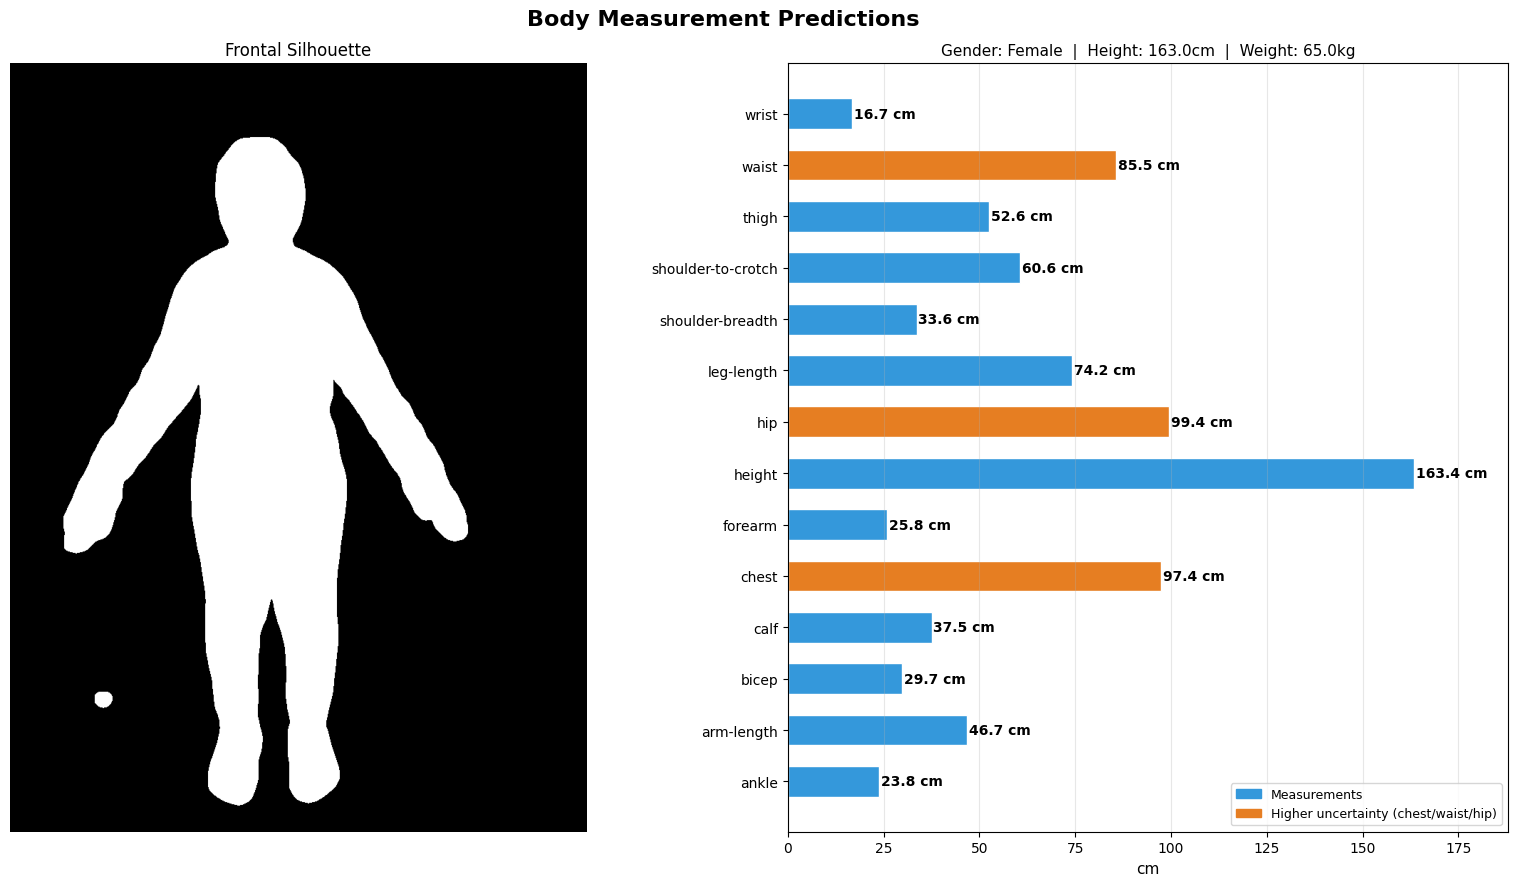


✓ Download from /kaggle/working/:
    → tflite_output/bodym_model_float32.tflite
    → scaler_params.json
    → predictions.png
    → silhouettes.png


In [17]:
display_results(onnx_predictions, GENDER, HEIGHT_CM, WEIGHT_KG, FRONT_PHOTO)

print('\n Download from /kaggle/working/:')
print('    → tflite_output/bodym_model_float32.tflite')
print('    → scaler_params.json')
print('    → predictions.png')
print('    → silhouettes.png')